In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
project_root = current.parent.parent
sys.path.append(str(project_root))

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()

In [2]:
from data.linear import LinearTaskGenerator, OutlierLinearGenerator
from models.attention_models import SelfAttentionModel
from train_and_test.train import train_ICL_model
from experiments.single_layer.test import compare_SignelLSA_matrices
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

d:\Users\nvr\Desktop\4 semester\Теория оптимизации\Проект\repo\AnalysisTransformersGD\code\train_and_test\train.py:132: SyntaxWarning: invalid escape sequence '\D'
  gd_label = f'GD Huber (lr = {best_lr:.4f}, $\Delta$ = {huber_delta:.2f})'


### Эксперименты со сходимостью лосса LSA к лоссу одного шага GD

In [10]:
NX = 11
NY = 1

N = 10
N_LAYERS = 2
N_HEADS_LIST = [4, 4]
USE_SOFTMAX = True
USE_LAYERNORM = False

W_STD = 1.0
X_RANGE = (-1, 1)

N_STEPS = 2000
BATCH_SIZE = 2048
LR = 0.001

LR_VALUES = np.logspace(-3, 2, 100)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = LinearTaskGenerator(nx=NX, ny=NY, x_range=X_RANGE, w_std=W_STD)
model = SelfAttentionModel(
	nx=NX,
	ny=NY,
	n_layers=N_LAYERS,
    n_heads_list=N_HEADS_LIST,
	use_softmax=USE_SOFTMAX,
	use_layernorm=USE_LAYERNORM)
optimizer = optim.AdamW(model.parameters(), lr=LR)
device

'cuda'

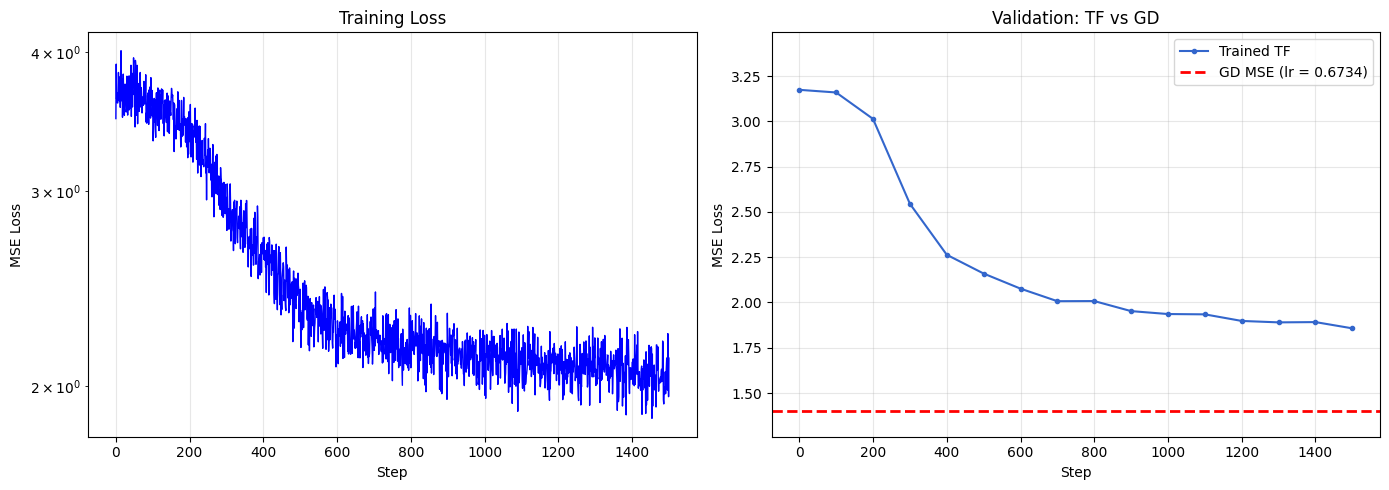

Training:  78%|███████▊  | 1566/2000 [00:29<00:08, 52.80it/s, gd_val=1.3986, tf_val=1.8571, train_loss=2.12]


KeyboardInterrupt: 

In [11]:
model, losses, tf_val, best_lr = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=100,
    lr_values=LR_VALUES
)

print(f'Best GD lr: {best_lr:.4f}')

In [10]:
def print_comparing_results(model, best_eta, device):
	results = compare_SignelLSA_matrices(
		model, 
		nx=NX, 
		ny=NY, 
		eta=best_eta,
		N=N, 
		device=device
	)

	print(f"Best eta: {best_eta:.4f}")
	print(f"Mean cosine similarity: {results['mean']['cosine_similarity']:.4f}")
	print(f"Mean relative error: {results['mean']['relative_error']:.4f}")
	print()
	print("Per-matrix cosine similarity:")
	for name in ['W_q', 'W_k', 'W_v', 'P']:
		r = results[name]
		print(f"  {name}: cos_sim={r['cosine_similarity']:.2f}, rel_err={r['relative_error']:.2f}")

print_comparing_results(model, best_eta, device)

Best eta: 1.5199
Mean cosine similarity: -0.0839
Mean relative error: 4.5612

Per-matrix cosine similarity:
  W_q: cos_sim=-0.05, rel_err=1.26
  W_k: cos_sim=-0.07, rel_err=1.27
  W_v: cos_sim=-0.08, rel_err=2.19
  P: cos_sim=-0.14, rel_err=13.52


### Замораживаем эталонные матрицы по очереди и учим все остальные

In [12]:
from experiments.single_layer.test import get_theoretical_gd_matrices

model = SingleLayerLSA(nx=NX, ny=NY).to(device)

def freeze_gd_matrix(model, type):
	W_q_gd, W_k_gd, W_v_gd, P_gd = get_theoretical_gd_matrices(NX, NY, eta=best_eta, N=N)

	with torch.no_grad():
		if type == 'Q':
			model.layer.W_q.weight.copy_(W_q_gd)
			model.layer.W_q.weight.requires_grad = False
		if type == 'K':
			model.layer.W_k.weight.copy_(W_k_gd)
			model.layer.W_k.weight.requires_grad = False
		if type == 'V':
			model.layer.W_v.weight.copy_(W_v_gd)
			model.layer.W_v.weight.requires_grad = False
		if type == 'P':
			model.layer.P.weight.copy_(P_gd)
			model.layer.P.weight.requires_grad = False

	for name, param in model.named_parameters():
		print(f"{name}: requires_grad = {param.requires_grad}")

freeze_gd_matrix(model, type='Q')

layer.W_q.weight: requires_grad = False
layer.W_k.weight: requires_grad = True
layer.W_v.weight: requires_grad = True
layer.P.weight: requires_grad = True


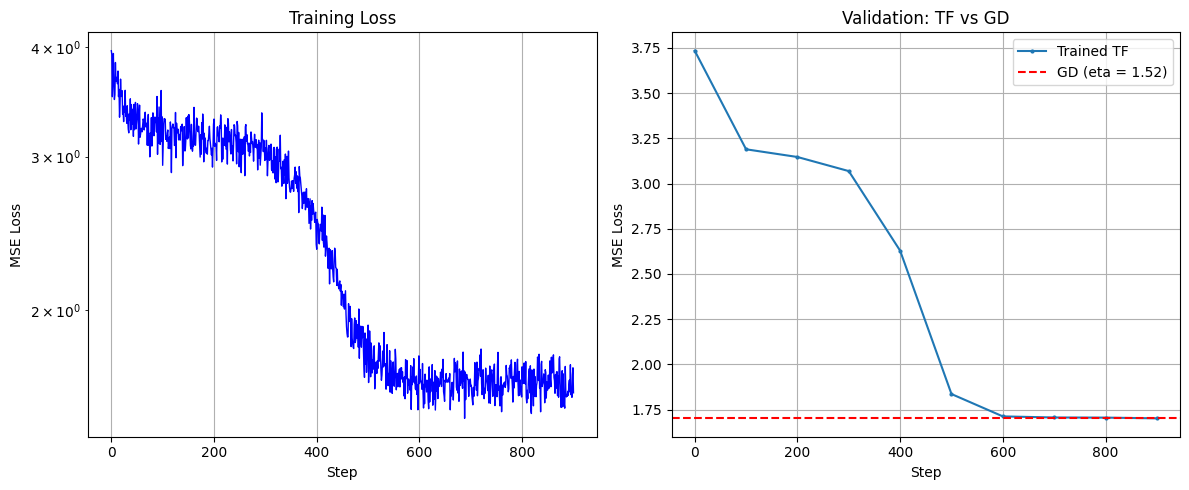

Training: 100%|██████████| 1000/1000 [01:17<00:00, 12.96it/s, gd_val=1.7037, tf_val=1.7016, train_loss=1.61]


In [13]:
optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [14]:
print_comparing_results(model, best_eta, device)

Best eta: 1.5199
Mean cosine similarity: 0.0291
Mean relative error: 3.8635

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=-0.95, rel_err=1.52
  W_v: cos_sim=0.08, rel_err=2.03
  P: cos_sim=-0.01, rel_err=11.90


In [15]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='K')

layer.W_q.weight: requires_grad = True
layer.W_k.weight: requires_grad = False
layer.W_v.weight: requires_grad = True
layer.P.weight: requires_grad = True


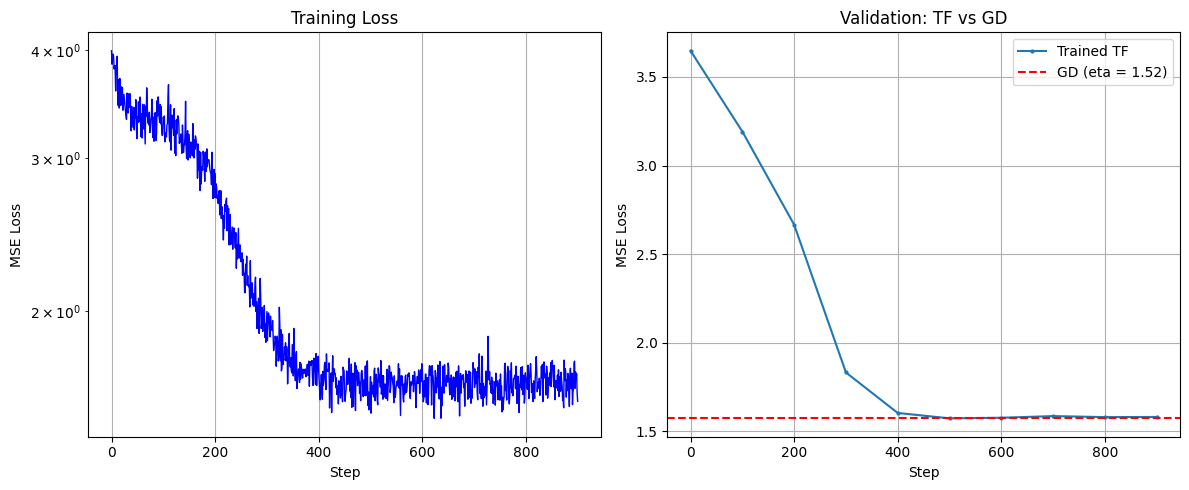

Training: 100%|██████████| 1000/1000 [00:41<00:00, 23.89it/s, gd_val=1.5747, tf_val=1.5817, train_loss=1.58]


In [77]:
optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [78]:
print_comparing_results(model, best_eta, device)

Best eta: 1.5199
Mean cosine similarity: 0.0921
Mean relative error: 3.9079

Per-matrix cosine similarity:
  W_q: cos_sim=-0.75, rel_err=1.35
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=0.15, rel_err=1.99
  P: cos_sim=-0.02, rel_err=12.29


In [81]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='V')

layer.W_q.weight: requires_grad = True
layer.W_k.weight: requires_grad = True
layer.W_v.weight: requires_grad = False
layer.P.weight: requires_grad = True


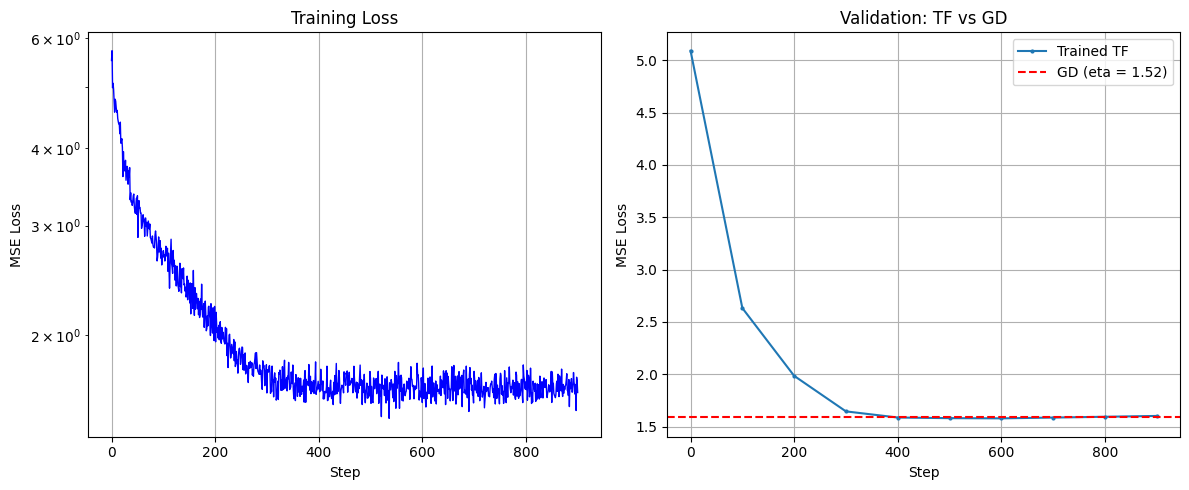

Training: 100%|██████████| 1000/1000 [01:07<00:00, 14.73it/s, gd_val=1.5898, tf_val=1.6029, train_loss=1.62]


In [82]:
optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [83]:
print_comparing_results(model, best_eta, device)

Best eta: 1.5199
Mean cosine similarity: 0.2721
Mean relative error: 3.7727

Per-matrix cosine similarity:
  W_q: cos_sim=-0.01, rel_err=1.27
  W_k: cos_sim=-0.06, rel_err=1.30
  W_v: cos_sim=1.00, rel_err=0.00
  P: cos_sim=0.16, rel_err=12.53


In [104]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='P')

layer.W_q.weight: requires_grad = True
layer.W_k.weight: requires_grad = True
layer.W_v.weight: requires_grad = True
layer.P.weight: requires_grad = False


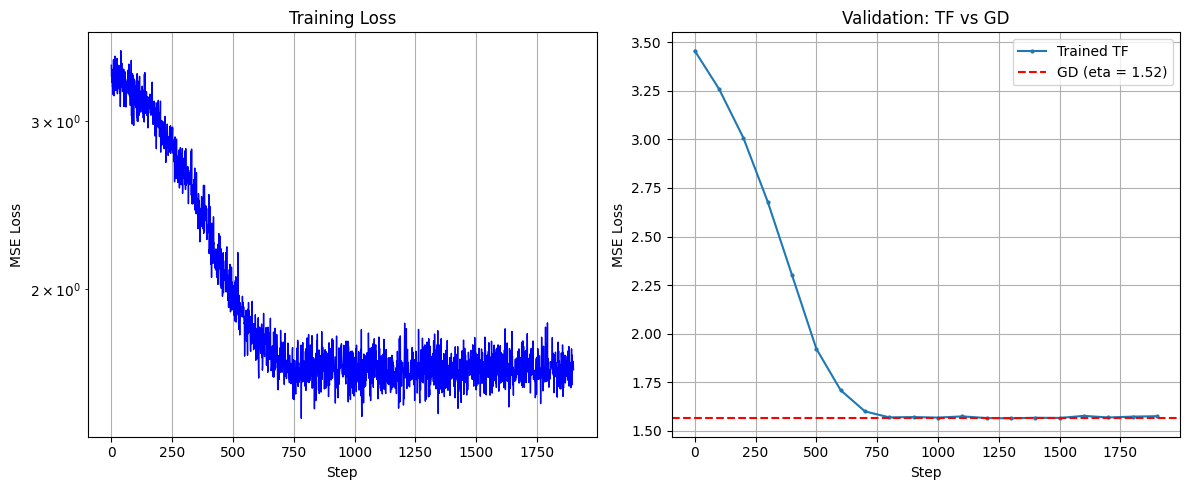

Training: 100%|██████████| 2000/2000 [01:16<00:00, 26.25it/s, gd_val=1.5665, tf_val=1.5756, train_loss=1.65]


In [105]:
optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=2000,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [106]:
print_comparing_results(model, best_eta, device)

Best eta: 1.5199
Mean cosine similarity: 0.3466
Mean relative error: 1.3962

Per-matrix cosine similarity:
  W_q: cos_sim=-0.04, rel_err=1.70
  W_k: cos_sim=0.01, rel_err=1.74
  W_v: cos_sim=0.42, rel_err=1.81
  P: cos_sim=1.00, rel_err=0.34


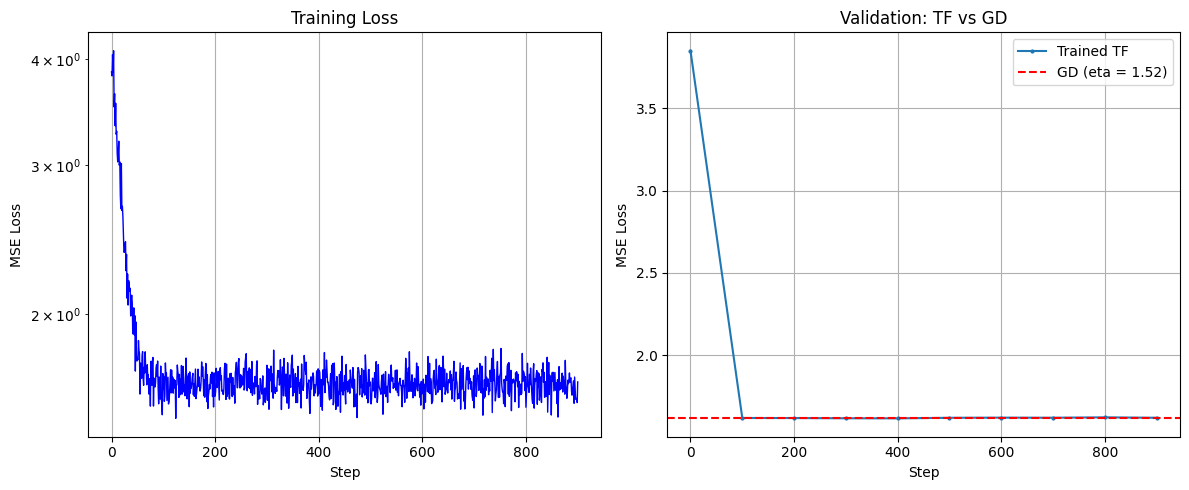

Training: 100%|██████████| 1000/1000 [00:44<00:00, 22.56it/s, gd_val=1.6201, tf_val=1.6214, train_loss=1.66]

Best eta: 1.5199
Mean cosine similarity: 0.4498
Mean relative error: 3.7005

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=-0.14, rel_err=2.28
  P: cos_sim=-0.06, rel_err=12.52


In [92]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')
freeze_gd_matrix(model, type='K')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

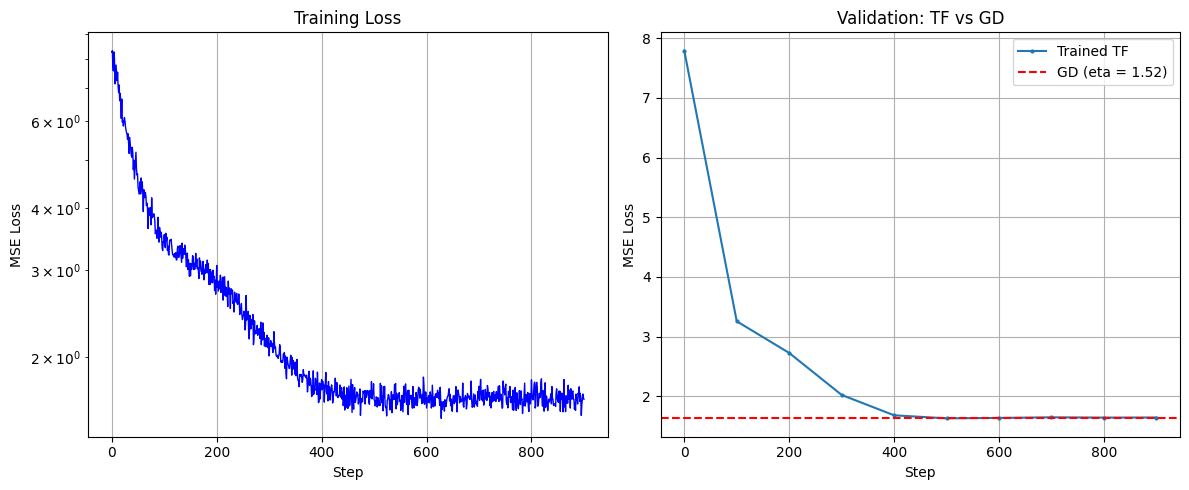

Training: 100%|██████████| 1000/1000 [00:37<00:00, 26.91it/s, gd_val=1.6364, tf_val=1.6422, train_loss=1.64]

Best eta: 1.5199
Mean cosine similarity: 0.2287
Mean relative error: 3.6007

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=-0.92, rel_err=1.48
  W_v: cos_sim=1.00, rel_err=0.00
  P: cos_sim=-0.17, rel_err=12.92


In [93]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')
freeze_gd_matrix(model, type='V')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

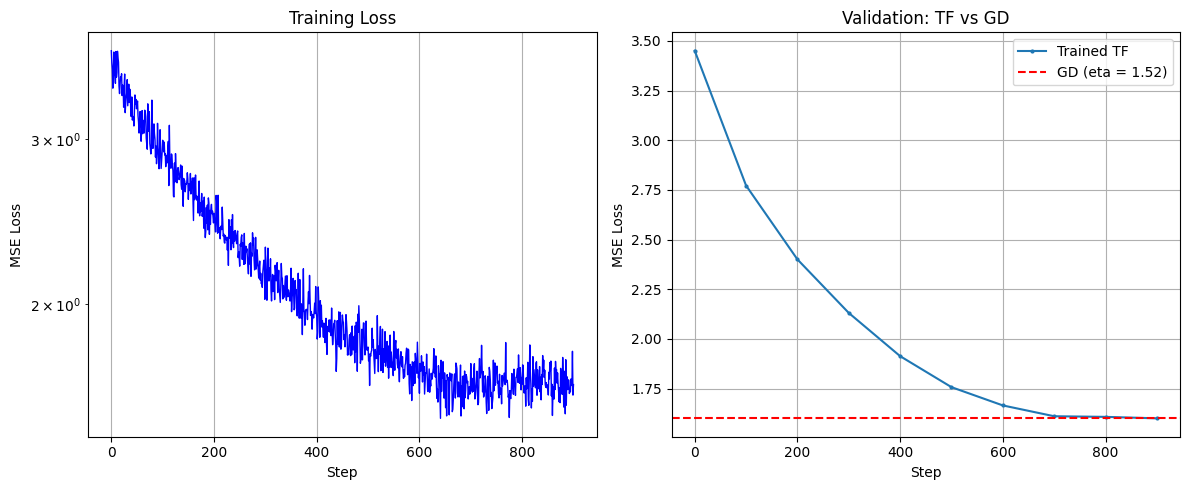

Training: 100%|██████████| 1000/1000 [00:44<00:00, 22.55it/s, gd_val=1.6000, tf_val=1.6002, train_loss=1.64]

Best eta: 1.5199
Mean cosine similarity: 0.5163
Mean relative error: 0.8844

Per-matrix cosine similarity:
  W_q: cos_sim=0.04, rel_err=1.48
  W_k: cos_sim=0.03, rel_err=1.71
  W_v: cos_sim=1.00, rel_err=0.00
  P: cos_sim=1.00, rel_err=0.34


In [94]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='P')
freeze_gd_matrix(model, type='V')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

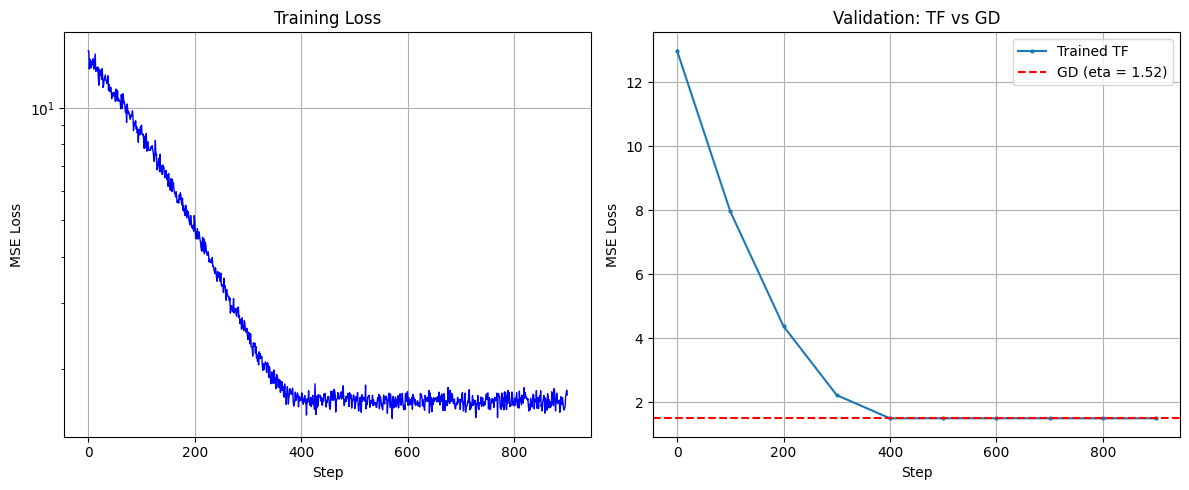

Training: 100%|██████████| 1000/1000 [00:38<00:00, 25.93it/s, gd_val=1.4922, tf_val=1.4929, train_loss=1.71]

Best eta: 1.5199
Mean cosine similarity: 0.7695
Mean relative error: 3.1635

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=1.00, rel_err=0.00
  P: cos_sim=0.08, rel_err=12.65


In [95]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')
freeze_gd_matrix(model, type='K')
freeze_gd_matrix(model, type='V')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

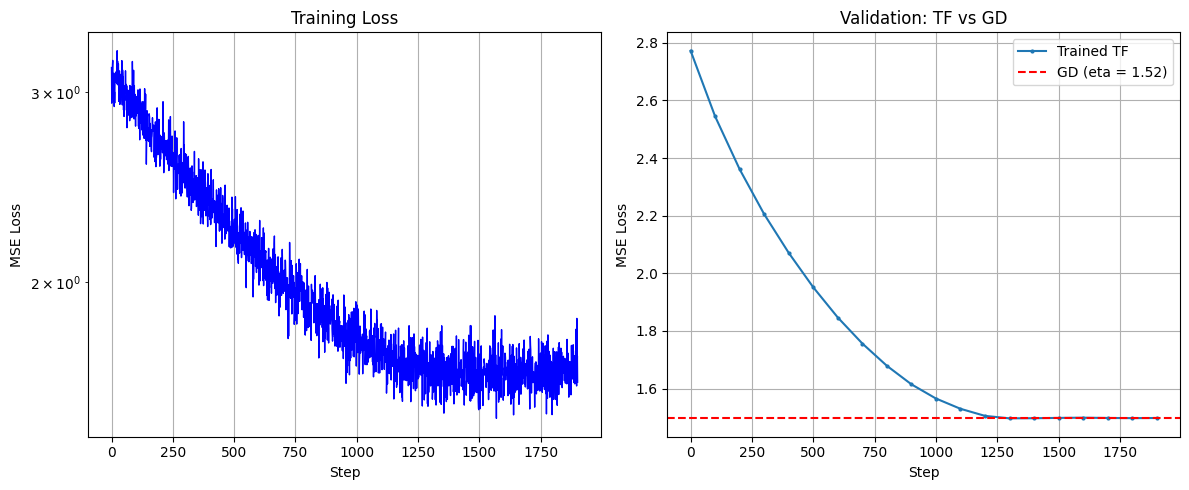

Training: 100%|██████████| 2000/2000 [01:52<00:00, 17.71it/s, gd_val=1.4995, tf_val=1.4982, train_loss=1.61]

Best eta: 1.5199
Mean cosine similarity: 0.9105
Mean relative error: 0.5549

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=0.64, rel_err=1.88
  P: cos_sim=1.00, rel_err=0.34


In [97]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')
freeze_gd_matrix(model, type='K')
freeze_gd_matrix(model, type='P')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=2000,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

### Еще несколько проверок для Q-K соотношения

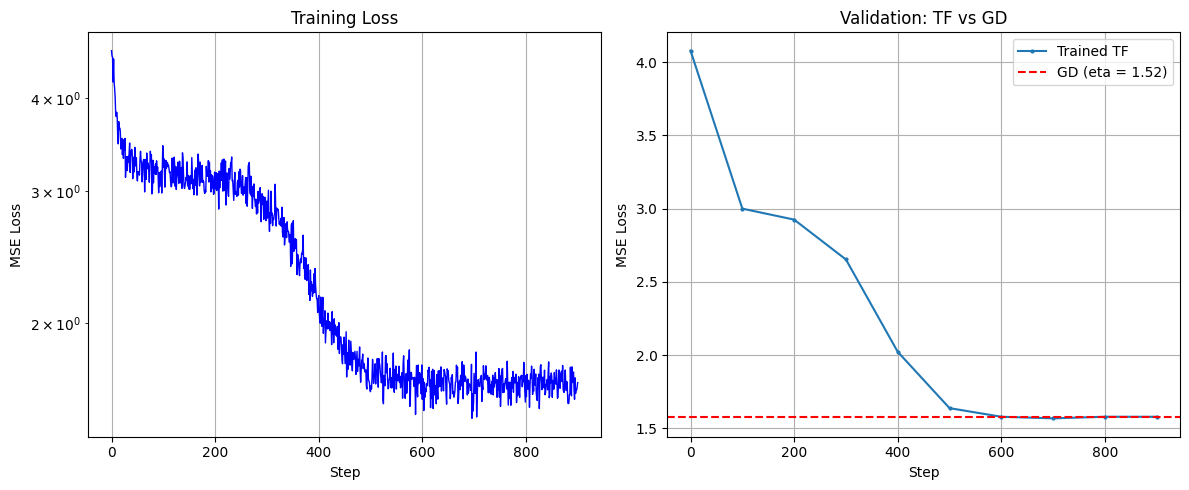

Training: 100%|██████████| 1000/1000 [00:37<00:00, 26.40it/s, gd_val=1.5742, tf_val=1.5785, train_loss=1.66]

Best eta: 1.5199
Mean cosine similarity: 0.3860
Mean relative error: 3.9759

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=0.90, rel_err=0.58
  W_v: cos_sim=-0.19, rel_err=2.25
  P: cos_sim=-0.17, rel_err=13.08


In [98]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

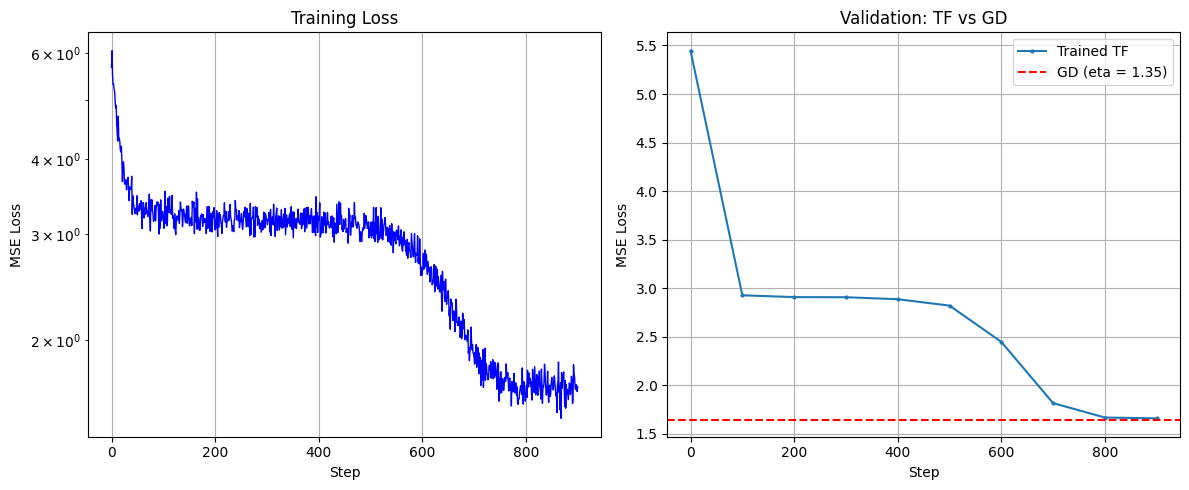

Training: 100%|██████████| 1000/1000 [00:51<00:00, 19.31it/s, gd_val=1.6356, tf_val=1.6572, train_loss=1.68]

Best eta: 1.3530
Mean cosine similarity: 0.0251
Mean relative error: 4.5449

Per-matrix cosine similarity:
  W_q: cos_sim=1.00, rel_err=0.00
  W_k: cos_sim=-0.94, rel_err=1.51
  W_v: cos_sim=0.15, rel_err=2.20
  P: cos_sim=-0.12, rel_err=14.47


In [100]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='Q')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

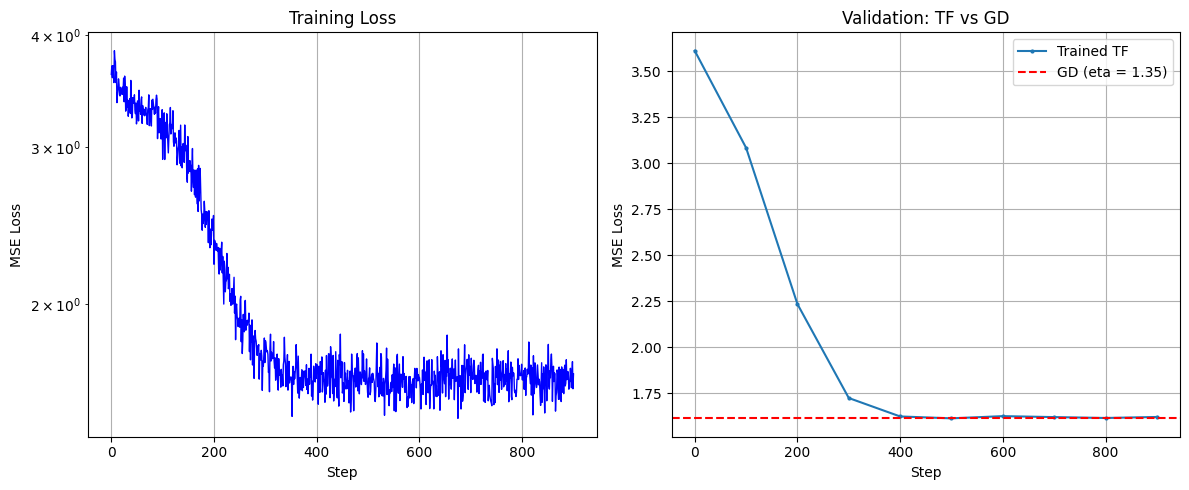

Training: 100%|██████████| 1000/1000 [00:38<00:00, 26.00it/s, gd_val=1.6160, tf_val=1.6215, train_loss=1.67]

Best eta: 1.3530
Mean cosine similarity: 0.3470
Mean relative error: 4.1642

Per-matrix cosine similarity:
  W_q: cos_sim=0.74, rel_err=0.75
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=-0.21, rel_err=2.20
  P: cos_sim=-0.15, rel_err=13.71


In [99]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='K')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)

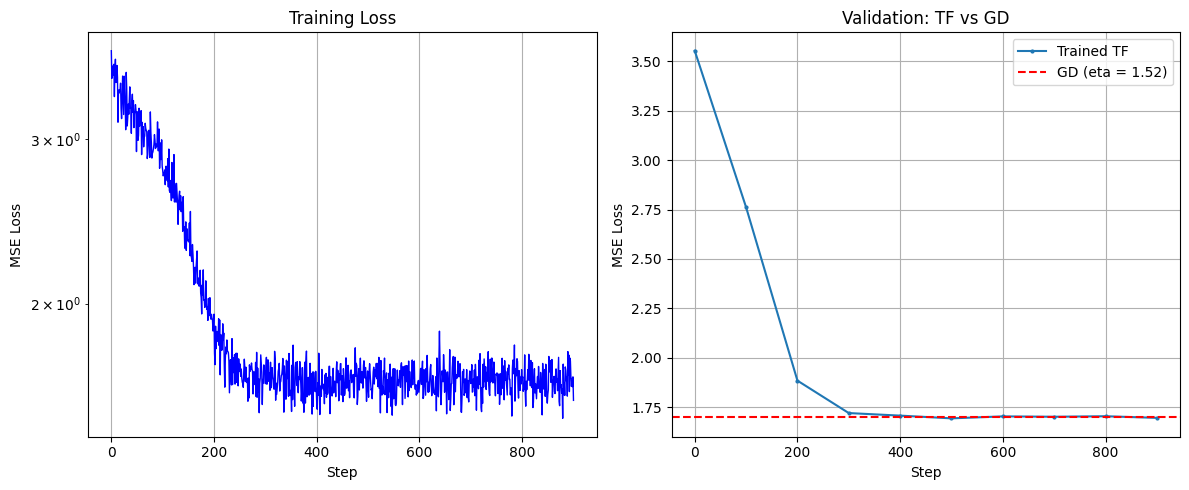

Training: 100%|██████████| 1000/1000 [00:37<00:00, 26.76it/s, gd_val=1.6988, tf_val=1.6954, train_loss=1.57]

Best eta: 1.5199
Mean cosine similarity: 0.0551
Mean relative error: 3.9915

Per-matrix cosine similarity:
  W_q: cos_sim=-0.77, rel_err=1.37
  W_k: cos_sim=1.00, rel_err=0.00
  W_v: cos_sim=-0.01, rel_err=2.14
  P: cos_sim=0.01, rel_err=12.46


In [101]:
model = SingleLayerLSA(nx=NX, ny=NY).to(device)
freeze_gd_matrix(model, type='K')

optimizer = optim.AdamW(model.parameters(), lr=LR)

model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

print_comparing_results(model, best_eta, device)